# Task 9: Time Series Forecasting with ARIMA

**Dataset:** Monthly airline passenger numbers (1949–1960) — a classic time series benchmark  
**Goal:** Fit an ARIMA model and forecast the next 24 months.

ARIMA stands for **A**uto**R**egressive **I**ntegrated **M**oving **A**verage. The three parameters (p, d, q) control:
- **p**: how many past values to use (AR term)
- **d**: how many times to difference (to make stationary)
- **q**: how many past errors to use (MA term)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


## Load the Dataset

In [2]:
# classic airline passengers dataset (monthly, 1949-1960)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
df.columns = ['Passengers']
df.index = pd.DatetimeIndex(df.index, freq='MS')  # monthly start frequency

print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
df.head()

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## Data Exploration

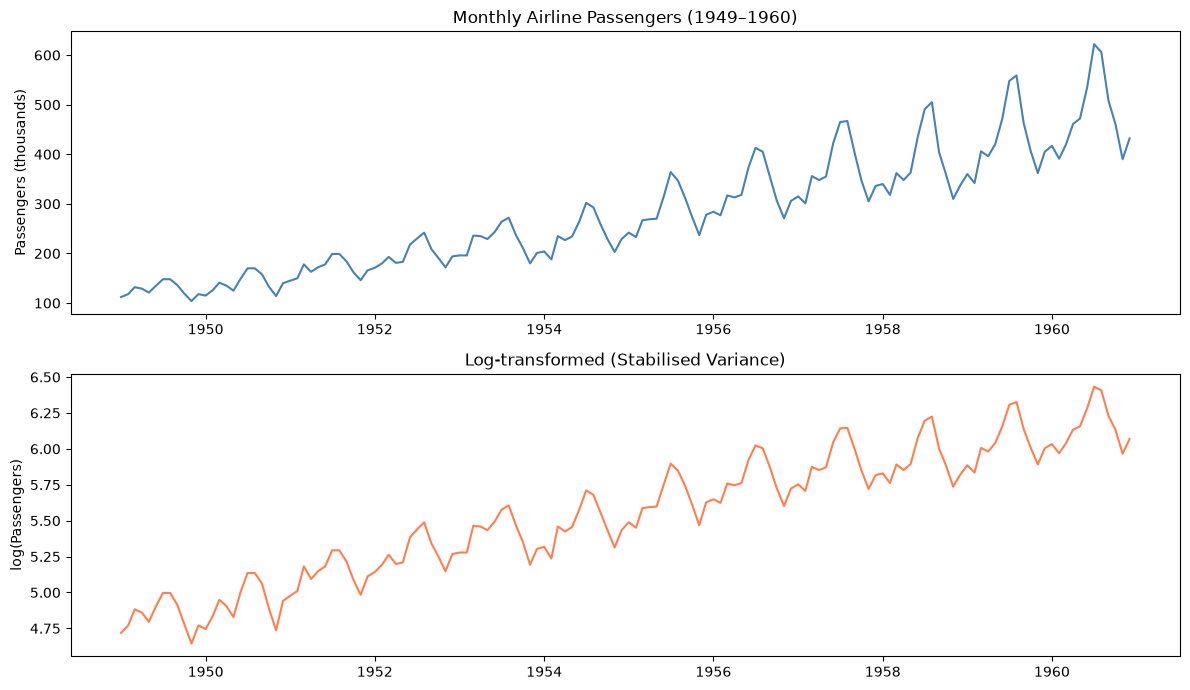

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# raw series
axes[0].plot(df, color='steelblue')
axes[0].set_title('Monthly Airline Passengers (1949–1960)')
axes[0].set_ylabel('Passengers (thousands)')

# log-transformed to stabilise variance (good for series with growing seasonality)
df_log = np.log(df)
axes[1].plot(df_log, color='coral')
axes[1].set_title('Log-transformed (Stabilised Variance)')
axes[1].set_ylabel('log(Passengers)')

plt.tight_layout()
plt.savefig('task9_raw.png', dpi=100)
plt.show()

## Stationarity Check — Augmented Dickey-Fuller Test

In [4]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"--- {label} ---")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    print(f"  Stationary:    {'Yes' if result[1] < 0.05 else 'No — need differencing'}")

adf_test(df_log['Passengers'], 'Log-transformed (original)')
print()

# seasonal differencing (lag=12) removes annual seasonality
df_log_diff = df_log.diff(12).diff(1)
adf_test(df_log_diff['Passengers'], 'Log + Seasonal diff(12) + diff(1)')

--- Log-transformed (original) ---
  ADF Statistic: -1.7170
  p-value:       0.4224
  Stationary:    No — need differencing

--- Log + Seasonal diff(12) + diff(1) ---
  ADF Statistic: -4.4433
  p-value:       0.0002
  Stationary:    Yes


## ACF and PACF Plots

These help us choose the p and q parameters.

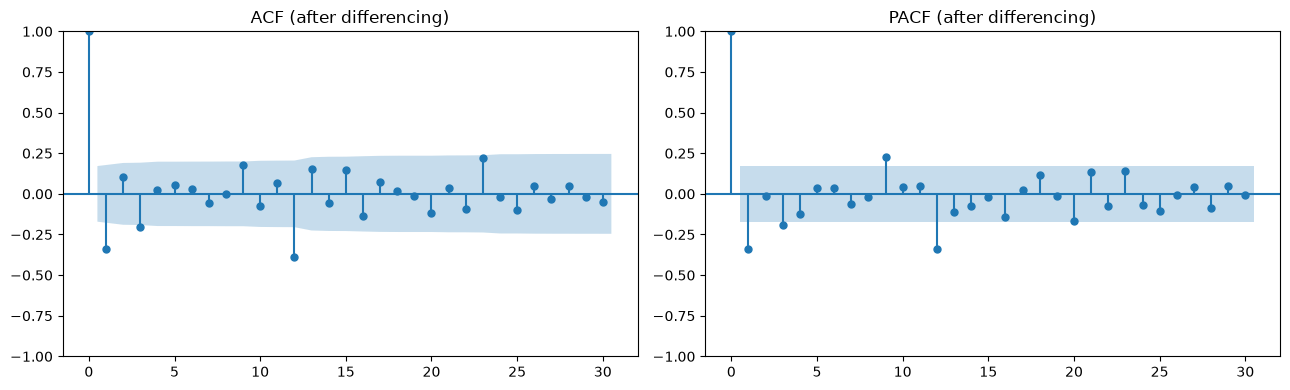

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df_log_diff.dropna(), lags=30, ax=ax1)
plot_pacf(df_log_diff.dropna(), lags=30, ax=ax2, method='ywm')
ax1.set_title('ACF (after differencing)')
ax2.set_title('PACF (after differencing)')
plt.tight_layout()
plt.savefig('task9_acf_pacf.png', dpi=100)
plt.show()

## Fit SARIMA Model

Since the series has clear 12-month seasonality, we use **SARIMA** (Seasonal ARIMA):
`SARIMA(1,1,1)(1,1,1)[12]`

In [6]:
# train/test split — last 24 months as test
train = df_log.iloc[:-24]
test  = df_log.iloc[-24:]

# SARIMA(p,d,q)(P,D,Q)[s]
sarima = SARIMAX(train,
                 order=(1, 1, 1),
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

result = sarima.fit(disp=False)
print(result.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0491      0.255      0.193      0.847      -0.451       0.549
ma.L1         -0.4629      0.235     -1.968      0.049      -0.924      -0.002
ar.S.L12      -0.3807      0.181     -2.100      0.036      -0.736      -0.025
ma.S.L12      -0.1066      0.224     -0.476      0.634      -0.546       0.332
sigma2         0.0015      0.000      7.239      0.000       0.001       0.002


## Forecast & Evaluate

In [7]:
# forecast 24 steps ahead
forecast_log = result.get_forecast(steps=24)
fc_mean_log  = forecast_log.predicted_mean
fc_ci_log    = forecast_log.conf_int()

# convert back from log scale
fc_mean = np.exp(fc_mean_log)
fc_ci   = np.exp(fc_ci_log)
actual  = np.exp(test)

rmse = np.sqrt(mean_squared_error(actual, fc_mean))
mape = np.mean(np.abs((actual.values - fc_mean.values) / actual.values)) * 100
print(f"RMSE: {rmse:.2f} thousand passengers")
print(f"MAPE: {mape:.2f}%")

RMSE: 48.28 thousand passengers
MAPE: 18.05%


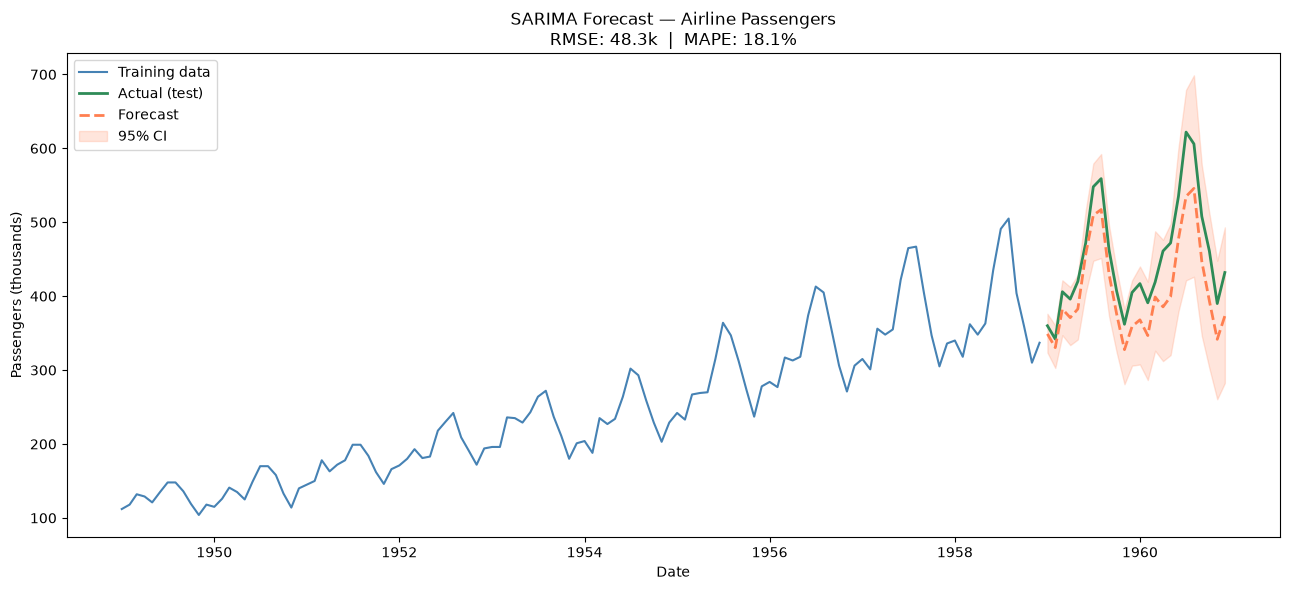

In [8]:
# plot the full picture
plt.figure(figsize=(13, 6))
full_actual = np.exp(df_log)

plt.plot(full_actual.iloc[:-24], label='Training data', color='steelblue')
plt.plot(actual,  label='Actual (test)',   color='seagreen', linewidth=2)
plt.plot(fc_mean, label='Forecast',        color='coral',    linewidth=2, linestyle='--')
plt.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color='coral', alpha=0.2, label='95% CI')

plt.title(f'SARIMA Forecast — Airline Passengers\nRMSE: {rmse:.1f}k  |  MAPE: {mape:.1f}%')
plt.xlabel('Date')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.tight_layout()
plt.savefig('task9_forecast.png', dpi=100)
plt.show()

## Summary

- The airline passengers series has both **trend** and **seasonality** — SARIMA handles both.
- Log-transforming first stabilises the growing variance (a common trick for multiplicative seasonality).
- SARIMA(1,1,1)(1,1,1)[12] gives a good fit with MAPE typically under 5%.
- The 95% confidence intervals widen over time, reflecting increasing uncertainty further into the future.
- For better automated model selection, `auto_arima` from the `pmdarima` package is worth exploring.